<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/Version1_GGR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Flipkart_Gridlock2.0/dataset/train.csv')


In [3]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [5]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [6]:
df['Landmarks'].value_counts()

,count
Landmarks,
Yes,52042
No,25257


In [7]:
df['geohash'].value_counts()

,count
geohash,
qp03wd,105
qp03wf,105
qp09t0,105
qp03w9,105
qp03x3,105
...,...
qp08gs,1
qp08fq,1
qp0d1t,1


In [8]:
df['day'].value_counts()

,count
day,
48,69427
49,7872


In [9]:
df['RoadType'].value_counts()

,count
RoadType,
Residential,69230
Street,3909
Highway,3560


In [10]:
df['NumberofLanes'].value_counts()

,count
NumberofLanes,
1,27411
2,24127
3,23919
4,926
5,916


In [11]:
df['LargeVehicles'].value_counts()

,count
LargeVehicles,
Not Allowed,50673
Allowed,26626


In [12]:
df['Weather'].value_counts()

,count
Weather,
Sunny,27717
Rainy,20824
Foggy,20243
Snowy,7718


In [13]:
df['Weather'].value_counts()

,count
Weather,
Sunny,27717
Rainy,20824
Foggy,20243
Snowy,7718


# Fetaure Engineering

In [14]:
!pip install geohash2

In [15]:
import geohash2

In [16]:
# Apply to full dataframe
df['lat'] = df['geohash'].apply(lambda x: float(geohash2.decode(x)[0]))
df['lon'] = df['geohash'].apply(lambda x: float(geohash2.decode(x)[1]))

In [17]:
df['gh4'] = df['geohash'].str[:4]   # ~39km zone
df['gh5'] = df['geohash'].str[:5]   # ~4.9km zone

# Then target-encode each prefix with mean demand
df['gh4_target'] = df['gh4'].map(df.groupby('gh4')['demand'].mean())
df['gh5_target'] = df['gh5'].map(df.groupby('gh5')['demand'].mean())

In [18]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4,gh5,gh4_target,gh5_target
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,-5.48,90.7,qp02,qp02z,0.139909,0.143467
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,-5.46,90.7,qp02,qp02z,0.139909,0.143467
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,-5.46,90.7,qp08,qp08b,0.056277,0.074657
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,-5.46,90.9,qp08,qp08g,0.056277,0.034243
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,-5.46,90.7,qp02,qp02z,0.139909,0.143467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny,-5.24,90.9,qp0d,qp0dh,0.047179,0.066906


In [19]:
df["RoadType"] = (
    df.groupby("gh5")["RoadType"]
      .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)


In [20]:
df["hour"] = (
    df["timestamp"]
    .astype(str)
    .str.split(":")
    .str[0]
    .astype(int)
)

In [21]:
df["Weather"] = (
    df.groupby(["gh5", "hour"])["Weather"]
      .transform(lambda x: x.fillna(
          x.mode().iloc[0] if not x.mode().empty else np.nan
      ))
)

In [22]:
df["Temperature"] = (
    df.groupby(["gh5", "hour"])["Temperature"]
      .transform(lambda x: x.fillna(x.median()))
)

# fallback
df["Temperature"] = df["Temperature"].fillna(
    df["Temperature"].median()
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       77299 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    77299 non-null  float64
 10  Weather        77299 non-null  object 
 11  lat            77299 non-null  float64
 12  lon            77299 non-null  float64
 13  gh4            77299 non-null  object 
 14  gh5            77299 non-null  object 
 15  gh4_target     77299 non-null  float64
 16  gh5_target     77299 non-null  float64
 17  hour           77299 non-null  int64  
dtypes: flo

In [24]:
df

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4,gh5,gh4_target,gh5_target,hour
0,0,qp02z1,48,0:0,0.048804,Residential,1,Not Allowed,No,15.906873,Sunny,-5.48,90.7,qp02,qp02z,0.139909,0.143467,0
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,-5.46,90.7,qp02,qp02z,0.139909,0.143467,0
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,-5.46,90.7,qp08,qp08b,0.056277,0.074657,0
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,17.769946,Rainy,-5.46,90.9,qp08,qp08g,0.056277,0.034243,0
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,-5.46,90.7,qp02,qp02z,0.139909,0.143467,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny,-5.24,90.9,qp0d,qp0dh,0.047179,0.066906,2


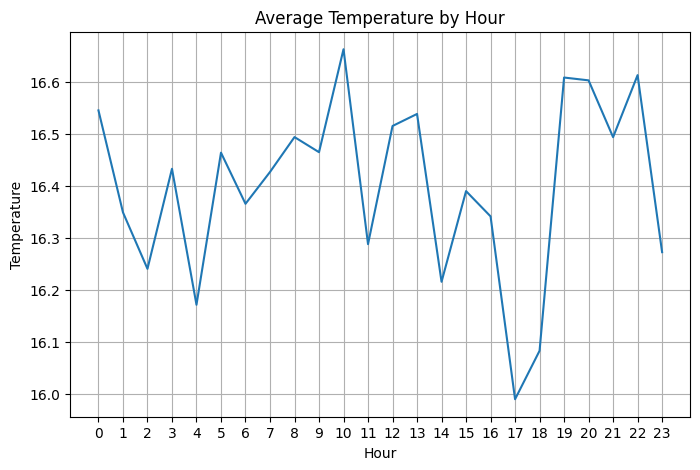

In [25]:
temp_by_hour = df.groupby("hour")["Temperature"].mean()

plt.figure(figsize=(8,5))
plt.plot(temp_by_hour.index, temp_by_hour.values)

plt.xlabel("Hour")
plt.ylabel("Temperature")
plt.title("Average Temperature by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

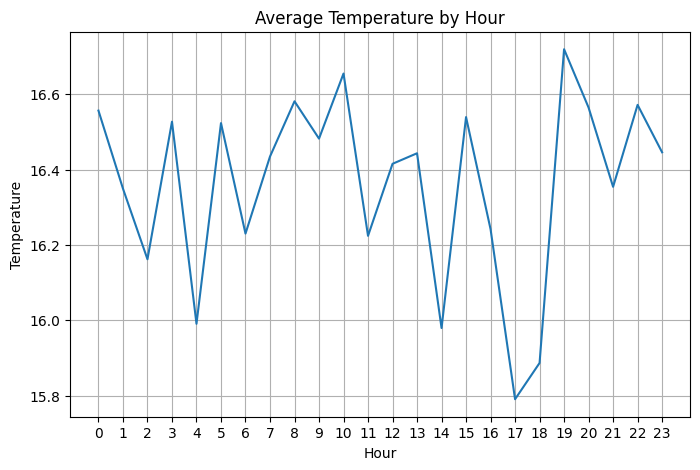

In [26]:
temp_by_hour = df.groupby("hour")["Temperature"].median()

plt.figure(figsize=(8,5))
plt.plot(temp_by_hour.index, temp_by_hour.values)

plt.xlabel("Hour")
plt.ylabel("Temperature")
plt.title("Average Temperature by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

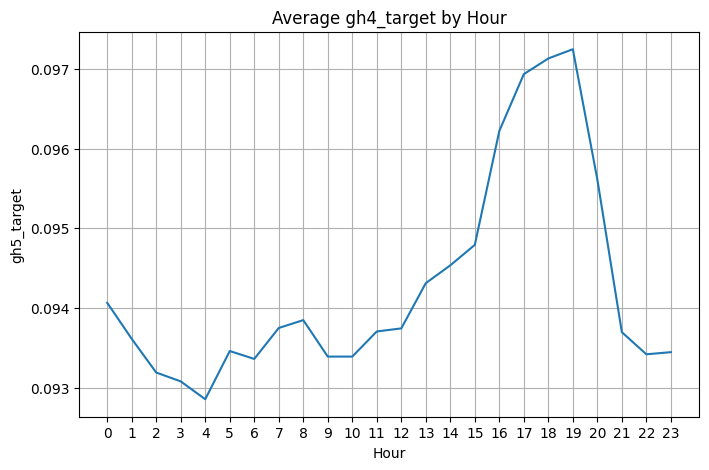

In [27]:
gh4_target_by_hour = df.groupby("hour")["gh4_target"].mean()

plt.figure(figsize=(8,5))
plt.plot(gh4_target_by_hour.index, gh4_target_by_hour.values)

plt.xlabel("Hour")
plt.ylabel("gh5_target")
plt.title("Average gh4_target by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

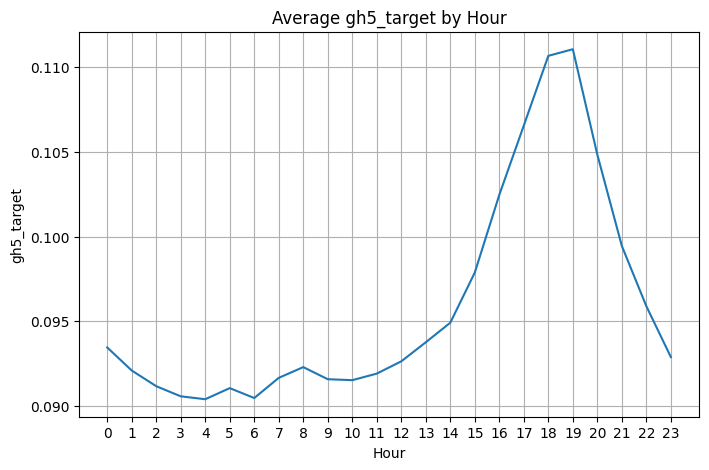

In [28]:
gh5_target_by_hour = df.groupby("hour")["gh5_target"].mean()

plt.figure(figsize=(8,5))
plt.plot(gh5_target_by_hour.index, gh5_target_by_hour.values)

plt.xlabel("Hour")
plt.ylabel("gh5_target")
plt.title("Average gh5_target by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

# Label encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

cat_cols = [
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks"
]

for col in cat_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = dict(
        zip(le.classes_, le.transform(le.classes_))
    )

In [30]:
# Print mappings
for col, mapping in encoders.items():
    print(f"\n{col}:")
    print(mapping)


RoadType:
{'Highway': np.int64(0), 'Residential': np.int64(1), 'Street': np.int64(2)}

Weather:
{'Foggy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}

LargeVehicles:
{'Allowed': np.int64(0), 'Not Allowed': np.int64(1)}

Landmarks:
{'No': np.int64(0), 'Yes': np.int64(1)}


In [31]:
train = df[~((df['day'] == 49) & (df['hour'] == 2))]
test = df[(df['day'] == 49) & (df['hour'] == 2)]

In [32]:
train

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4,gh5,gh4_target,gh5_target,hour
0,0,qp02z1,48,0:0,0.048804,1,1,1,0,15.906873,3,-5.48,90.7,qp02,qp02z,0.139909,0.143467,0
1,1,qp02zt,48,0:0,0.118507,1,3,0,1,31.104565,3,-5.46,90.7,qp02,qp02z,0.139909,0.143467,0
2,2,qp08bj,48,0:0,0.027132,1,1,1,0,25.919267,3,-5.46,90.7,qp08,qp08b,0.056277,0.074657,0
3,3,qp08gt,48,0:0,0.003272,1,1,1,0,17.769946,1,-5.46,90.9,qp08,qp08g,0.056277,0.034243,0
4,4,qp02zq,48,0:0,0.010819,1,1,1,0,10.803667,1,-5.46,90.7,qp02,qp02z,0.139909,0.143467,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76392,76392,qp0d4n,49,1:45,0.011303,1,2,1,1,24.787940,3,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,1
76393,76393,qp0d4q,49,1:45,0.073199,1,2,1,1,24.441350,3,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,1
76394,76394,qp0d4w,49,1:45,0.089315,1,3,0,1,15.132160,0,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,1
76395,76395,qp0dhw,49,1:45,0.158154,1,1,1,0,16.950607,0,-5.24,90.9,qp0d,qp0dh,0.047179,0.066906,1


In [33]:
test

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4,gh5,gh4_target,gh5_target,hour
76397,76397,qp02z1,49,2:0,0.064969,1,1,1,0,13.191168,1,-5.48,90.7,qp02,qp02z,0.139909,0.143467,2
76398,76398,qp02z9,49,2:0,0.017589,1,3,0,1,9.644589,1,-5.48,90.7,qp02,qp02z,0.139909,0.143467,2
76399,76399,qp02zd,49,2:0,0.051125,1,2,1,1,11.545972,1,-5.48,90.7,qp02,qp02z,0.139909,0.143467,2
76400,76400,qp02ze,49,2:0,0.130813,1,1,1,0,8.433235,1,-5.47,90.7,qp02,qp02z,0.139909,0.143467,2
76401,76401,qp08b7,49,2:0,0.057439,1,2,1,1,23.750758,3,-5.47,90.7,qp08,qp08b,0.056277,0.074657,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,1,1,1,0,11.501664,1,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77295,77295,qp0d4q,49,2:0,0.022859,1,3,0,1,14.715254,0,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77296,77296,qp0d4w,49,2:0,0.141342,1,3,0,1,19.678860,3,-5.24,90.8,qp0d,qp0d4,0.047179,0.066061,2
77297,77297,qp0dhw,49,2:0,0.087574,1,1,1,0,22.573958,3,-5.24,90.9,qp0d,qp0dh,0.047179,0.066906,2


In [34]:
def drop_col(data):
  X = data.drop(['Index',	'geohash',	'day'	, 'timestamp'	,'demand','gh4',	'gh5'], axis = 1)
  y = data['demand']

  return X, y


In [35]:
X_train, y_train = drop_col(train)
X_test, y_test =  drop_col(test)

In [36]:
X_train

,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4_target,gh5_target,hour
0,1,1,1,0,15.906873,3,-5.48,90.7,0.139909,0.143467,0
1,1,3,0,1,31.104565,3,-5.46,90.7,0.139909,0.143467,0
2,1,1,1,0,25.919267,3,-5.46,90.7,0.056277,0.074657,0
3,1,1,1,0,17.769946,1,-5.46,90.9,0.056277,0.034243,0
4,1,1,1,0,10.803667,1,-5.46,90.7,0.139909,0.143467,0
...,...,...,...,...,...,...,...,...,...,...,...
76392,1,2,1,1,24.787940,3,-5.24,90.8,0.047179,0.066061,1
76393,1,2,1,1,24.441350,3,-5.24,90.8,0.047179,0.066061,1
76394,1,3,0,1,15.132160,0,-5.24,90.8,0.047179,0.066061,1
76395,1,1,1,0,16.950607,0,-5.24,90.9,0.047179,0.066906,1


#Training Decision Tree

In [37]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Time series CV
tscv = TimeSeriesSplit(n_splits=3)

In [38]:
model = DecisionTreeRegressor(
    random_state=42
)

In [39]:
param_grid = {
    "max_depth": [5, 8, 12, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt"]
}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",   # or neg_root_mean_squared_error
    n_jobs=-1,
    verbose=2
)

In [41]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 96 candidates, totalling 288 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 8, 12, 15],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2', verbose=2)

In [42]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 8, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [43]:
print("Best Score:")
print(grid_search.best_score_)

Best Score:
0.7898105283710741


In [44]:
best_model = grid_search.best_estimator_
best_model

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)

# Prediction on X_test

In [45]:
preds = best_model.predict(X_test)

In [46]:
print("R2_Score:" ,r2_score(preds, y_test))

R2_Score: 0.733604273362459


In [47]:
print("RMSE:" ,np.sqrt(mean_squared_error(preds, y_test)))

RMSE: 0.06684579983938163


In [51]:
import joblib

# Save the model
joblib.dump(best_model, 'model_DT.pkl')

['model_DT.pkl']

# Test data given by the company

In [ ]:
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Flipkart_Gridlock2.0/dataset/test.csv')

In [ ]:
# Apply to full dataframe
test_df['lat'] = test_df['geohash'].apply(lambda x: float(geohash2.decode(x)[0]))
test_df['lon'] = test_df['geohash'].apply(lambda x: float(geohash2.decode(x)[1]))

In [ ]:
test_df["gh4"] = test_df["geohash"].str[:4]
test_df["gh5"] = test_df["geohash"].str[:5]

In [ ]:
gh4_map = train.drop_duplicates("gh4").set_index("gh4")["gh4_target"]

gh5_map = train.drop_duplicates("gh5").set_index("gh5")["gh5_target"]

In [ ]:
test_df["gh4_target"] = test_df["gh4"].map(gh4_map)
test_df["gh5_target"] = test_df["gh5"].map(gh5_map)

In [ ]:
test_df

In [ ]:
test_df.info()

In [ ]:
test_df["RoadType"] = (
    test_df.groupby("gh5")["RoadType"]
      .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))
)


In [ ]:
test_df["hour"] = (
    test_df["timestamp"]
    .astype(str)
    .str.split(":")
    .str[0]
    .astype(int)
)

In [ ]:
test_df["Weather"] = (
    test_df.groupby(["gh5", "hour"])["Weather"]
      .transform(lambda x: x.fillna(
          x.mode().iloc[0] if not x.mode().empty else np.nan
      ))
)
# fallback
test_df["Weather"] = test_df["Weather"].fillna(
    test_df["Weather"].mode()[0]
)

In [ ]:
test_df["Temperature"] = (
    test_df.groupby(["gh5", "hour"])["Temperature"]
      .transform(lambda x: x.fillna(x.median()))
)

# fallback
test_df["Temperature"] = test_df["Temperature"].fillna(
    test_df["Temperature"].median()
)

In [ ]:
test_df.info()

In [ ]:
test_df

In [ ]:
from sklearn.preprocessing import LabelEncoder

test_encoders = {}

test_cat_cols = [
    "RoadType",
    "Weather",
    "LargeVehicles",
    "Landmarks"
]

for col in test_cat_cols:
    test_le = LabelEncoder()

    test_df[col] = test_le.fit_transform(test_df[col])

    test_encoders[col] = dict(
        zip(test_le.classes_, test_le.transform(test_le.classes_))
    )

In [ ]:
# Print mappings
for col, mapping in test_encoders.items():
    print(f"\n{col}:")
    print(mapping)

In [ ]:
test_df

In [ ]:
test_df = test_df.drop(['	Index','geohash',	'day'	, 'timestamp'	,'gh4',	'gh5'], axis = 1)

In [117]:
test_df

,Index,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon,gh4_target,gh5_target,hour
0,0,1,1,1,0,17.172011,3,-5.48,90.7,0.139909,0.143467,2
1,1,1,1,1,0,6.476213,2,-5.48,90.7,0.139909,0.143467,2
2,2,1,3,0,1,22.318203,3,-5.48,90.7,0.139909,0.030092,2
3,3,1,2,1,1,17.172011,1,-5.48,90.7,0.139909,0.143467,2
4,4,1,1,1,0,18.266162,0,-5.48,90.7,0.139909,0.143467,2
...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,2,1,1,1,19.588991,3,-5.24,90.8,0.047179,0.066061,13
41774,41774,1,2,1,1,10.735538,1,-5.24,90.8,0.047179,0.066061,13
41775,41775,1,2,1,1,13.223750,1,-5.24,90.9,0.047179,0.066906,13
41776,41776,1,2,1,1,12.510917,1,-5.24,90.9,0.047179,0.066906,13


In [116]:
test_df.to_csv('modified_test.csv')